In [1]:
!pip install kagglehub pandas scikit-learn matplotlib

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
path = kagglehub.dataset_download(
    "muhamedumarjamil/house-price-prediction-dataset"
)

print("Dataset Path:", path)

100%|██████████| 292k/292k [00:00<00:00, 61.6MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/muhamedumarjamil/house-price-prediction-dataset/versions/1


In [4]:
files = os.listdir(path)

print(files)

['house_prices_dataset.csv']


In [5]:
csv_file = os.path.join(path, files[0])

df = pd.read_csv(csv_file)

In [6]:
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [7]:
print(df.shape)

print(df.columns)

df.info()

(10000, 5)
Index(['square_feet', 'num_rooms', 'age', 'distance_to_city(km)', 'price'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [8]:
df.isnull().sum()

,0
square_feet,0
num_rooms,0
age,0
distance_to_city(km),0
price,0


In [9]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded successfully")

Categorical columns encoded successfully


In [10]:
target_column = "price"

X = df.drop(target_column, axis=1)

y = df[target_column]

In [11]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 4)
(2000, 4)


In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [14]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[316636.89860441 245793.09538071 222084.4079465  231463.17523019
 378538.87517034]


In [15]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error:", mae)

print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 15596.120539083642
Root Mean Squared Error: 19658.174316560537


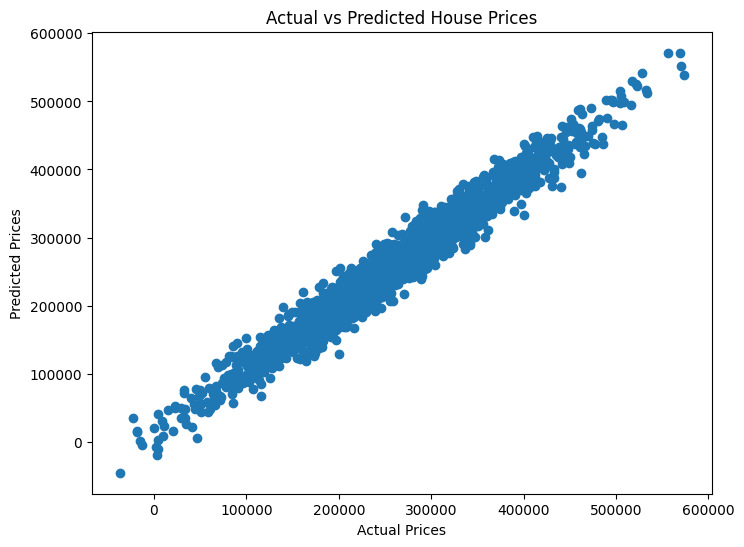

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()